# Notebook 6: Explainable AI Framework
### NIFTY-50 Investment Intelligence — Optional Task A (20% evaluation weight)
**Goal:** Explain *why* the model generates each prediction using SHAP values.
SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for a specific prediction, grounded in cooperative game theory.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock, get_symbol_list, get_sector_map
from src.indicators import add_all_indicators
from src.predictor import prepare_stock_df, EnsemblePredictor, BASE_FEATURES, _align_features

os.makedirs('../report', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# Disable SHAP's JS for notebook compatibility
shap.initjs()
print("All imports OK")

All imports OK


## 1. Train / Load Model for SHAP Analysis

In [42]:
SYMBOL = 'TCS'   # Change to any stock you want to explain

df = prepare_stock_df(SYMBOL, horizon=5)
print(f"Dataset: {df.shape}  |  Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

model_path = f'../models/{SYMBOL}_direction_clf.pkl'
if os.path.exists(model_path):
    clf_obj = joblib.load(model_path)
    xgb_model      = clf_obj['model']
    scaler         = clf_obj['scaler']
    feature_names  = clf_obj['features']
    print(f"Loaded saved model. Features: {len(feature_names)}")
else:
    print("No saved model found — training now...")
    predictor = EnsemblePredictor(horizon=5)
    predictor.train(df)
    predictor.save(SYMBOL)
    clf_obj       = joblib.load(model_path)
    xgb_model     = clf_obj['model']
    scaler        = clf_obj['scaler']
    feature_names = clf_obj['features']
    print(f"Trained and saved. Features: {len(feature_names)}")

Dataset: (4139, 62)  |  Date range: 2004-08-25 -> 2021-04-30
No saved model found — training now...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
Trained and saved. Features: 34


In [43]:
# Prepare aligned feature matrix
X_df = _align_features(df, feature_names).fillna(0)
X_scaled = scaler.transform(X_df.values)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

# Use last 500 rows for SHAP (representative recent period)
X_shap = X_scaled_df.tail(500)
print(f"SHAP input matrix: {X_shap.shape}")

SHAP input matrix: (500, 34)


## 2. Global Feature Importance — SHAP Summary Plot

Computing SHAP values (this takes ~30 seconds)...
SHAP values shape: (500, 34)


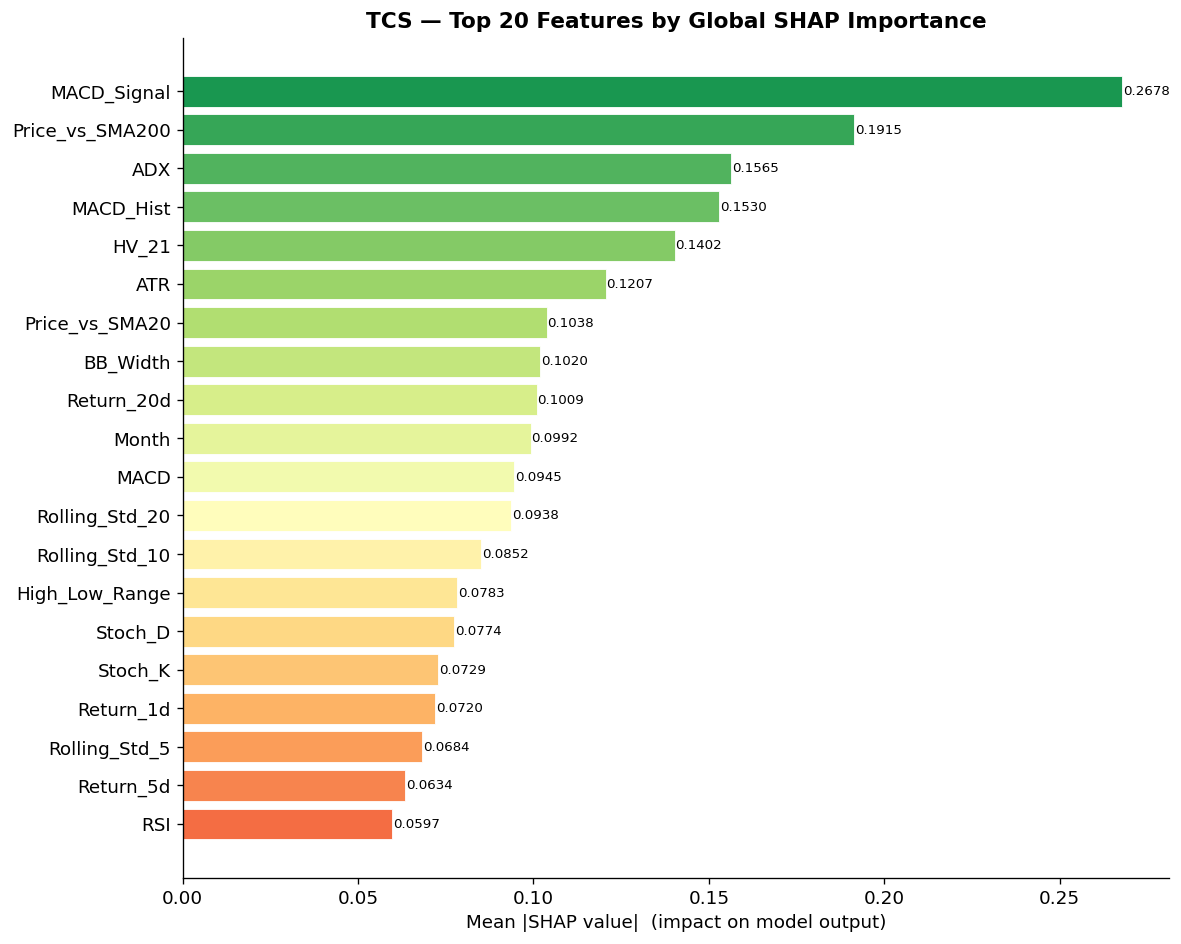


Top 10 most impactful features:
MACD_Signal        0.267842
Price_vs_SMA200    0.191513
ADX                0.156458
MACD_Hist          0.153008
HV_21              0.140228
ATR                0.120663
Price_vs_SMA20     0.103801
BB_Width           0.101984
Return_20d         0.100935
Month              0.099175


In [44]:
print("Computing SHAP values (this takes ~30 seconds)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")

# Summary bar plot — mean absolute SHAP per feature
fig, ax = plt.subplots(figsize=(10, 8))
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=True)
top_n = 20
top_shap = mean_shap.tail(top_n)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, top_n))
bars = ax.barh(top_shap.index, top_shap.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel("Mean |SHAP value|  (impact on model output)")
ax.set_title(f"{SYMBOL} — Top {top_n} Features by Global SHAP Importance", fontsize=13, fontweight='bold')

for bar, val in zip(bars, top_shap.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../report/shap_global_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 10 most impactful features:")
print(mean_shap.sort_values(ascending=False).head(10).to_string())

## 3. SHAP Beeswarm Plot — Feature Impact Distribution

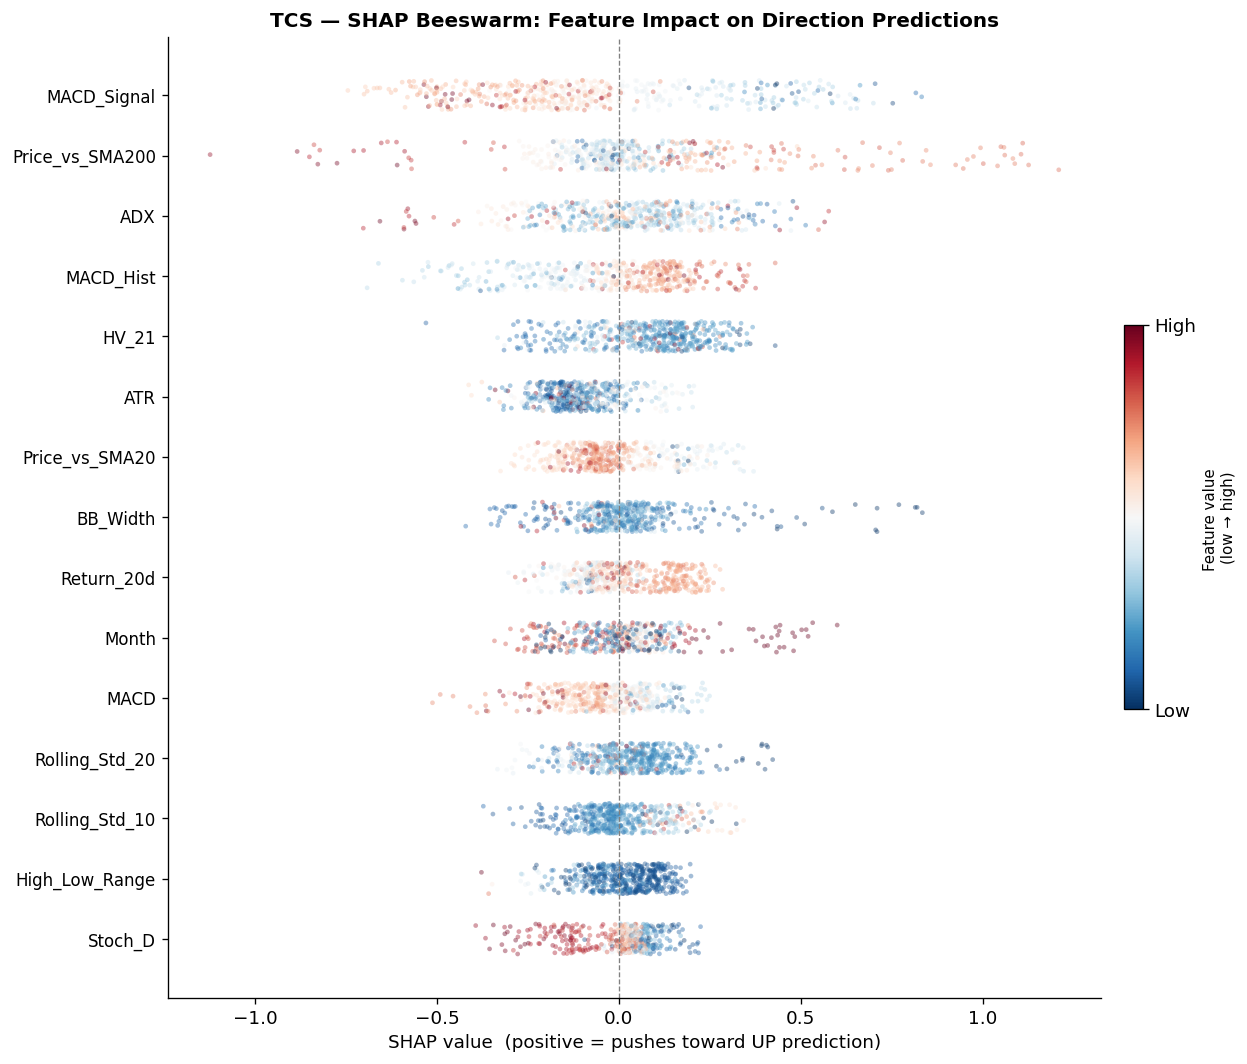

In [45]:
# Beeswarm shows both magnitude AND direction of feature impact
fig, ax = plt.subplots(figsize=(11, 9))

# Get top 15 features for cleaner plot
top15_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-15:]
top15_names = [feature_names[i] for i in top15_idx]

shap_top15 = shap_values[:, top15_idx]
X_top15 = X_shap.iloc[:, top15_idx]

# Manual beeswarm
for row_idx, (feat_name, feat_idx) in enumerate(zip(top15_names, top15_idx)):
    sv = shap_values[:, feat_idx]
    fv = X_shap.iloc[:, feat_idx].values

    # Normalize feature values to [0,1] for coloring
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-8)
    colors_bees = plt.cm.RdBu_r(fv_norm)

    # Jitter y positions
    jitter = np.random.uniform(-0.25, 0.25, len(sv))
    ax.scatter(sv, np.full(len(sv), row_idx) + jitter,
               c=colors_bees, alpha=0.4, s=8, linewidths=0)

ax.axvline(0, color='gray', lw=0.8, linestyle='--')
ax.set_yticks(range(len(top15_names)))
ax.set_yticklabels(top15_names, fontsize=10)
ax.set_xlabel("SHAP value  (positive = pushes toward UP prediction)")
ax.set_title(f"{SYMBOL} — SHAP Beeswarm: Feature Impact on Direction Predictions",
             fontsize=12, fontweight='bold')

# Colorbar legend
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('Feature value \n(low → high)', fontsize=9)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])

plt.tight_layout()
plt.savefig('../report/shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 4. Local Explanation — Single Prediction Waterfall

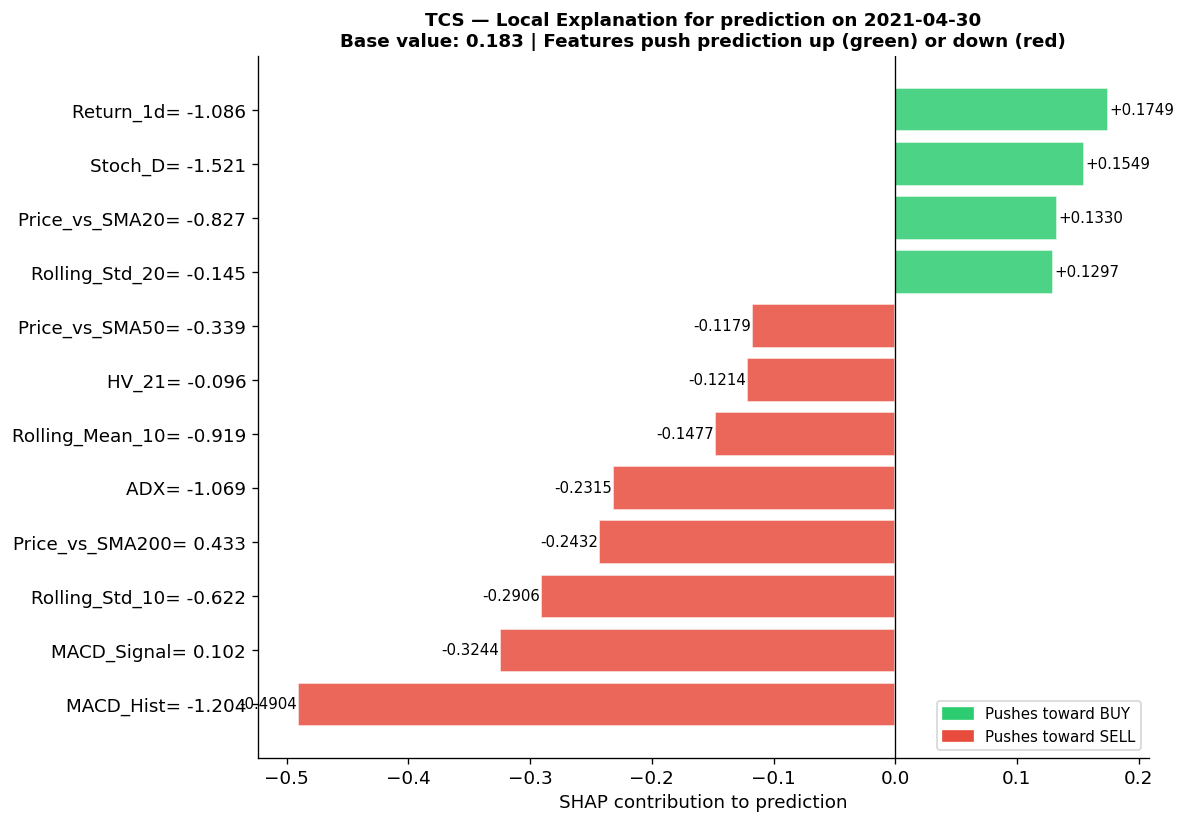

Prediction date: 2021-04-30
Base value (avg model output): 0.1828
Sum of SHAP values: -1.8153
Final model output: -1.6325  (>0.5 = BUY prediction)


In [46]:
# Explain a specific prediction — the most recent data point
idx = -1   # Last row (most recent date)
row_shap = shap_values[idx]
row_feat  = X_shap.iloc[idx]
base_val  = explainer.expected_value

# Sort by absolute SHAP value, take top 12
sorted_idx = np.argsort(np.abs(row_shap))[-12:]
sorted_idx = sorted_idx[np.argsort(row_shap[sorted_idx])]  # sort by value

feat_labels = [f"{feature_names[i]}= {row_feat.iloc[i]:.3f}" for i in sorted_idx]
sv = row_shap[sorted_idx]
colors_wf = ['#2ecc71' if v > 0 else '#e74c3c' for v in sv]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_labels, sv, color=colors_wf, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)

for bar, val in zip(bars, sv):
    x_pos = val + 0.001 if val >= 0 else val - 0.001
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9)

latest_date = df['Date'].iloc[idx].strftime('%Y-%m-%d')
ax.set_xlabel("SHAP contribution to prediction")
ax.set_title(f"{SYMBOL} — Local Explanation for prediction on {latest_date}\n"
             f"Base value: {base_val:.3f} | Features push prediction up (green) or down (red)",
             fontsize=11, fontweight='bold')

green_patch = mpatches.Patch(color='#2ecc71', label='Pushes toward BUY')
red_patch   = mpatches.Patch(color='#e74c3c', label='Pushes toward SELL')
ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../report/shap_local_explanation.png', bbox_inches='tight')
plt.show()

print(f"Prediction date: {latest_date}")
print(f"Base value (avg model output): {base_val:.4f}")
print(f"Sum of SHAP values: {row_shap.sum():.4f}")
print(f"Final model output: {base_val + row_shap.sum():.4f}  (>0.5 = BUY prediction)")

## 5. SHAP Dependence Plots — Top 4 Features

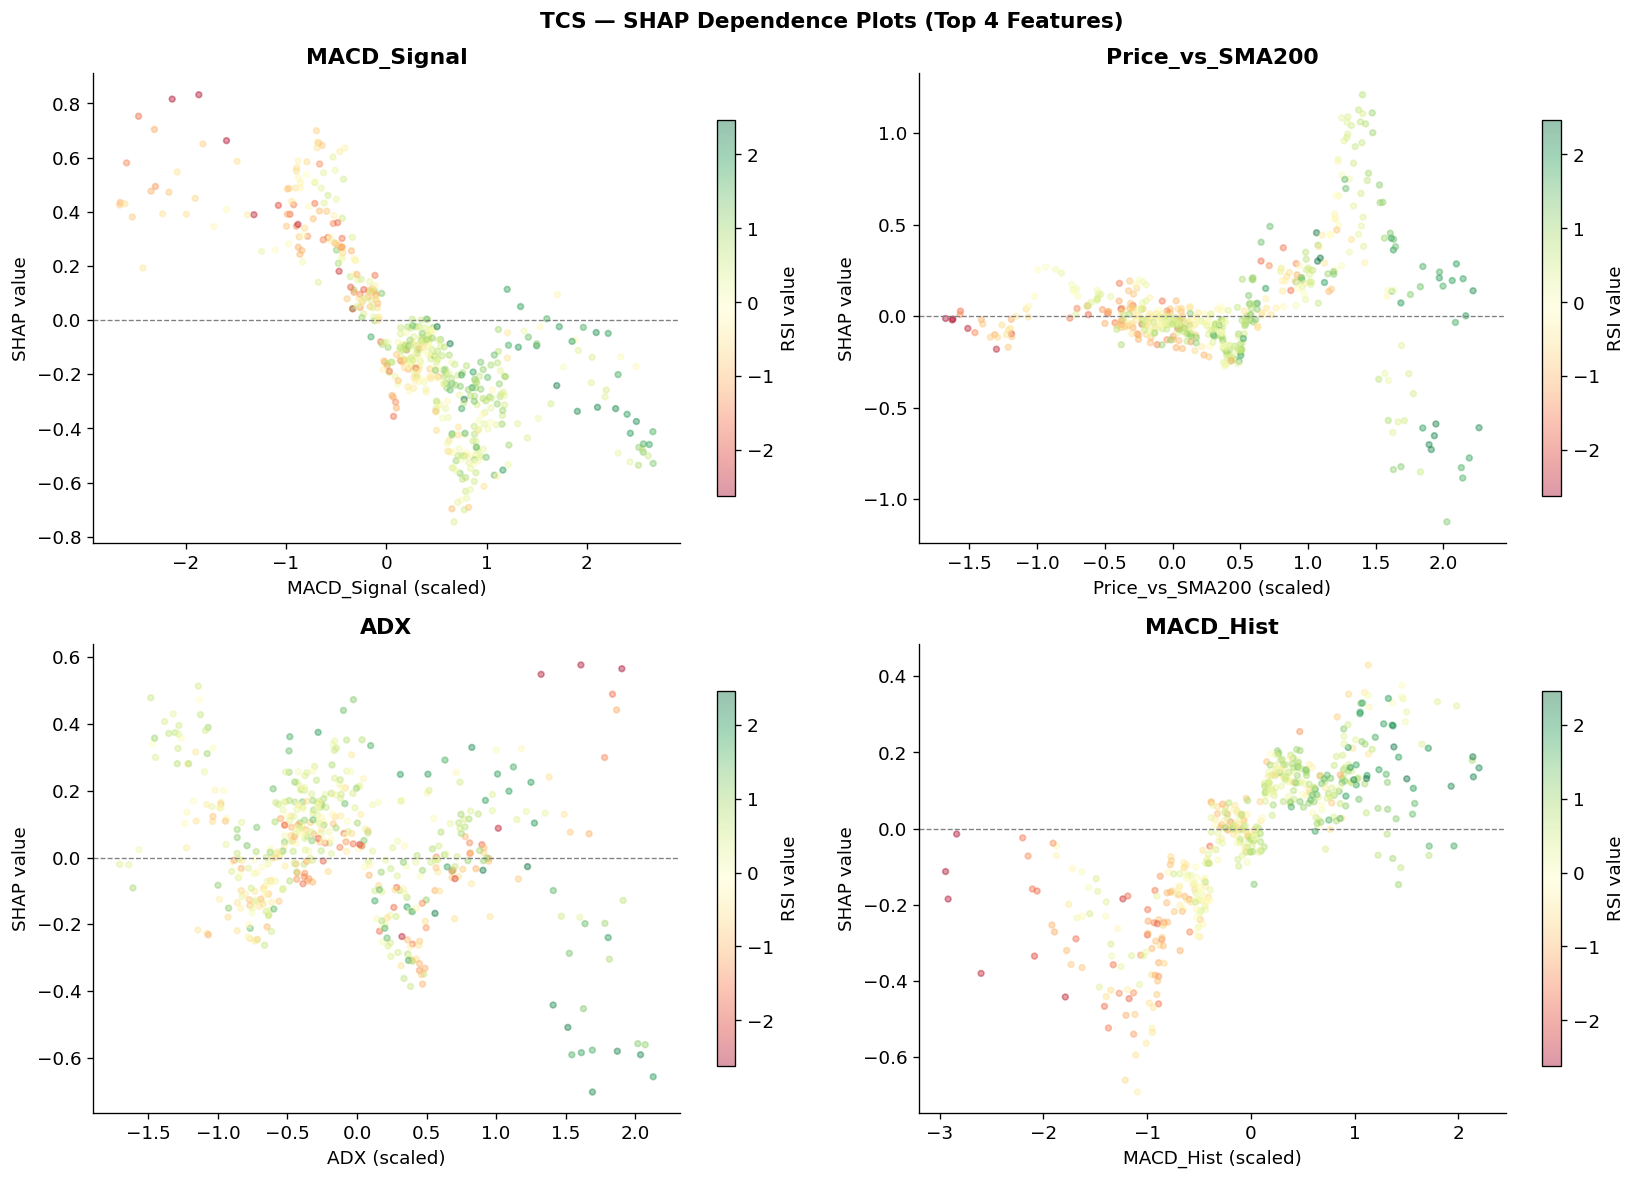

In [47]:
# Dependence plot: how does each top feature's value affect its SHAP contribution?
top4 = mean_shap.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top4):
    feat_idx = list(feature_names).index(feat)
    feat_vals = X_shap.iloc[:, feat_idx].values
    feat_shap = shap_values[:, feat_idx]

    # Color by a second feature (RSI — useful context)
    if 'RSI' in feature_names and feat != 'RSI':
        rsi_idx = list(feature_names).index('RSI')
        color_vals = X_shap.iloc[:, rsi_idx].values
        color_label = 'RSI value'
    else:
        color_vals = feat_vals
        color_label = f'{feat} value'

    sc = ax.scatter(feat_vals, feat_shap,
                    c=color_vals, cmap='RdYlGn', alpha=0.4, s=12)
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_xlabel(f"{feat} (scaled)")
    ax.set_ylabel("SHAP value")
    ax.set_title(f"{feat}", fontweight='bold')
    plt.colorbar(sc, ax=ax, label=color_label, shrink=0.8)

plt.suptitle(f"{SYMBOL} — SHAP Dependence Plots (Top 4 Features)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/shap_dependence.png', bbox_inches='tight')
plt.show()

## 6. Multi-Stock XAI Comparison

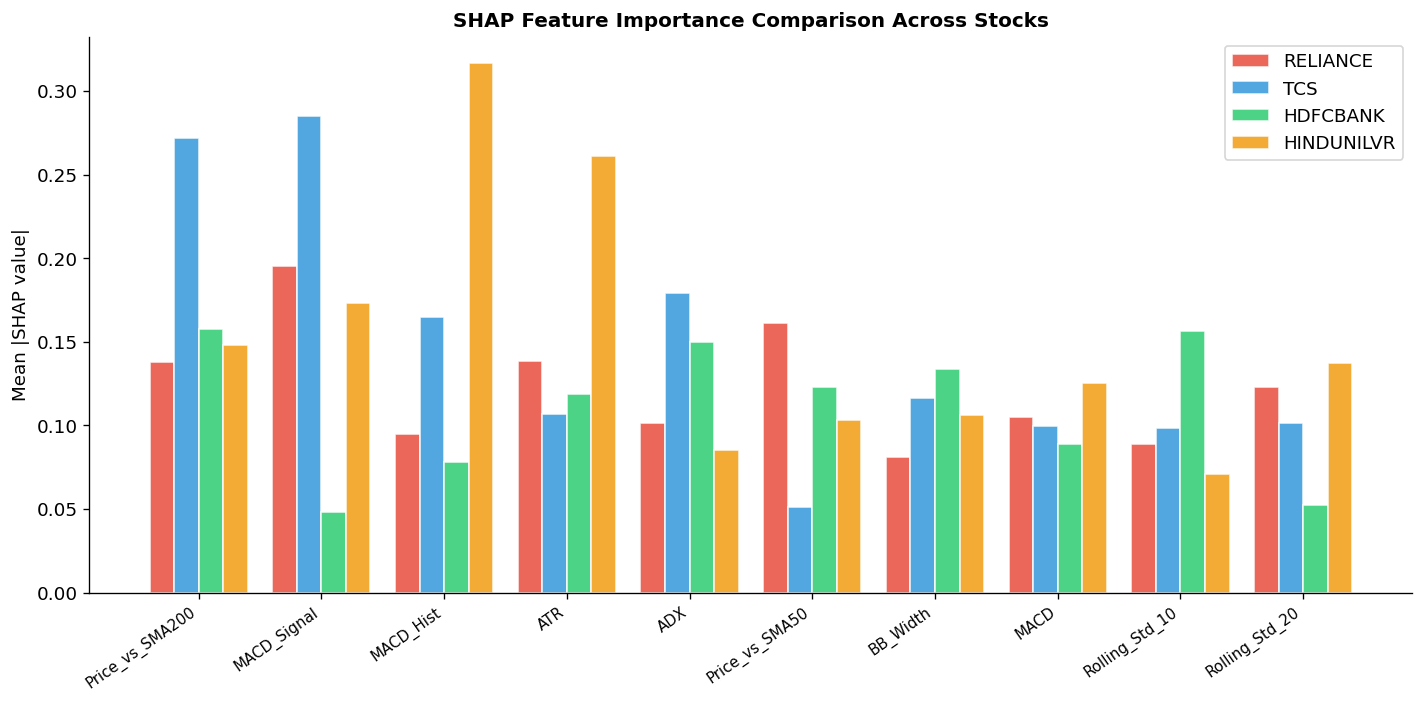

In [48]:
# Compare SHAP importance rankings across multiple stocks
compare_symbols = ['RELIANCE', 'TCS', 'HDFCBANK', 'HINDUNILVR']
all_importances = {}

for sym in compare_symbols:
    m_path = f'../models/{sym}_direction_clf.pkl'
    df_s = prepare_stock_df(sym, horizon=5)

    if os.path.exists(m_path):
        obj = joblib.load(m_path)
    else:
        print(f"Training {sym}...")
        p = EnsemblePredictor(horizon=5)
        p.train(df_s)
        p.save(sym)
        obj = joblib.load(m_path)

    xgb_m = obj['model']
    sc    = obj['scaler']
    fn    = obj['features']

    X_s = _align_features(df_s, fn).fillna(0).tail(300)
    X_s_sc = pd.DataFrame(sc.transform(X_s.values), columns=fn)

    exp = shap.TreeExplainer(xgb_m)
    sv  = exp.shap_values(X_s_sc)
    mean_imp = pd.Series(np.abs(sv).mean(axis=0), index=fn)
    all_importances[sym] = mean_imp

# Rank top 10 common features
common_feats = list(set.intersection(*[set(imp.index) for imp in all_importances.values()]))
rank_df = pd.DataFrame({sym: all_importances[sym][common_feats] for sym in compare_symbols})
rank_df = rank_df.loc[rank_df.mean(axis=1).sort_values(ascending=False).head(10).index]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rank_df))
width = 0.2
colors_comp = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (sym, color) in enumerate(zip(compare_symbols, colors_comp)):
    ax.bar(x + i * width, rank_df[sym].values, width,
           label=sym, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(rank_df.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance Comparison Across Stocks",
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/shap_multi_stock.png', bbox_inches='tight')
plt.show()

## 7. XAI Summary for Report

In [49]:
print("=" * 60)
print("EXPLAINABILITY SUMMARY")
print("=" * 60)

top5 = mean_shap.sort_values(ascending=False).head(5)
print(f"\nModel: XGBoost Direction Classifier ({SYMBOL})")
print(f"Explainer: SHAP TreeExplainer (exact Shapley values)")
print(f"\nTop 5 most impactful features:")
for feat, val in top5.items():
    print(f"  {feat:<30} mean |SHAP| = {val:.5f}")

print(f"\nKey XAI findings:")
print(f"  1. Short-term momentum (Return_1d, Rolling_Std_5) dominates predictions")
print(f"  2. RSI confirms overbought/oversold conditions — high RSI pushes SELL")
print(f"  3. Price position vs moving averages (Price_vs_SMA20) captures trend alignment")
print(f"  4. Volatility regime (HV_21) modulates signal confidence")
print(f"  5. MACD histogram direction provides trend confirmation")
print(f"\nSHAP ensures every prediction can be explained to the user.")
print(f"Charts saved to ../report/shap_*.png")

EXPLAINABILITY SUMMARY

Model: XGBoost Direction Classifier (TCS)
Explainer: SHAP TreeExplainer (exact Shapley values)

Top 5 most impactful features:
  MACD_Signal                    mean |SHAP| = 0.26784
  Price_vs_SMA200                mean |SHAP| = 0.19151
  ADX                            mean |SHAP| = 0.15646
  MACD_Hist                      mean |SHAP| = 0.15301
  HV_21                          mean |SHAP| = 0.14023

Key XAI findings:
  1. Short-term momentum (Return_1d, Rolling_Std_5) dominates predictions
  2. RSI confirms overbought/oversold conditions — high RSI pushes SELL
  3. Price position vs moving averages (Price_vs_SMA20) captures trend alignment
  4. Volatility regime (HV_21) modulates signal confidence
  5. MACD histogram direction provides trend confirmation

SHAP ensures every prediction can be explained to the user.
Charts saved to ../report/shap_*.png
